# Sífilis em Ilhéus e Itabuna - análises específicas por tipo

Este notebook aprofunda campos próprios de cada ficha: sífilis adquirida, sífilis em gestante e sífilis congênita.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def encontrar_projeto():
    for candidato in [Path.cwd(), *Path.cwd().parents]:
        if (candidato / "Dados").exists() and (candidato / "Sifilis").exists():
            return candidato
        if (candidato / "DataSUS" / "Dados").exists():
            return candidato / "DataSUS"
    raise FileNotFoundError("Não foi possível localizar a pasta DataSUS.")

PROJECT_DIR = encontrar_projeto()
SIFILIS_DIR = PROJECT_DIR / "Sifilis"
DATA_DIR = PROJECT_DIR / "Dados"
OUTPUT_DIR = SIFILIS_DIR / "dados_processados"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SIFILIS_DIR) not in sys.path:
    sys.path.insert(0, str(SIFILIS_DIR))

from sifilis_utils import (
    ANOS_ESPERADOS,
    CODIGOS_CIDADES,
    TIPOS_SIFILIS,
    carregar_agregados_demograficos,
    carregar_agregados_especificos,
    carregar_agregados_qualidade,
    carregar_agregados_temporais,
    carregar_base_cidades,
    caminho_artefato,
    exigir_cache_processado,
    exibir_markdown,
    formatar_inteiro,
    formatar_percentual,
    ler_tabela,
    salvar_figura,
    verificar_cache_processado,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

exigir_cache_processado(OUTPUT_DIR)

especificos = carregar_agregados_especificos(OUTPUT_DIR)
class_sifa = especificos["sifilis_adquirida_classificacao_cidades"]
sifa_criterio = especificos["sifilis_sifa_criterio"]
sifa_evolucao = especificos["sifilis_sifa_evolucao"]
sifa_doenca_trabalho = especificos["sifilis_sifa_doenca_trabalho"]
sifg_testes = especificos["sifilis_sifg_testes_tratamento"]
sifg_parceria = especificos["sifilis_sifg_parceria"]
sifc_pre_natal = especificos["sifilis_sifc_pre_natal_tratamento"]
sifc_sinais = especificos["sifilis_sifc_sinais_clinicos"]
sifc_evolucao = especificos["sifilis_sifc_evolucao"]
campos_unidade_df = especificos["sifilis_campos_unidade_disponiveis"]
notificacao_municipio = especificos["sifilis_municipio_notificacao_residentes_cidades"]

In [2]:
def plot_barras_categoria(base, categoria_col, valor_col, titulo, nome_figura, limite=8):
    principais = base.groupby(categoria_col)[valor_col].sum().sort_values(ascending=False).head(limite).index
    plot_df = base[base[categoria_col].isin(principais)]
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=plot_df, x=categoria_col, y=valor_col, hue="cidade", ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("Registros")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="Cidade")
    salvar_figura(fig, OUTPUT_DIR, nome_figura)
    plt.show()
    return base.sort_values(valor_col, ascending=False)

resumo_especificos = pd.DataFrame({
    "tabela": ["classificação", "critério", "gestante", "congênita"],
    "linhas": [len(class_sifa), len(sifa_criterio), len(sifg_testes), len(sifc_pre_natal)],
})
resumo_especificos

,tabela,linhas
0,classificação,7
1,critério,6
2,gestante,38
3,congênita,30


## Sífilis adquirida

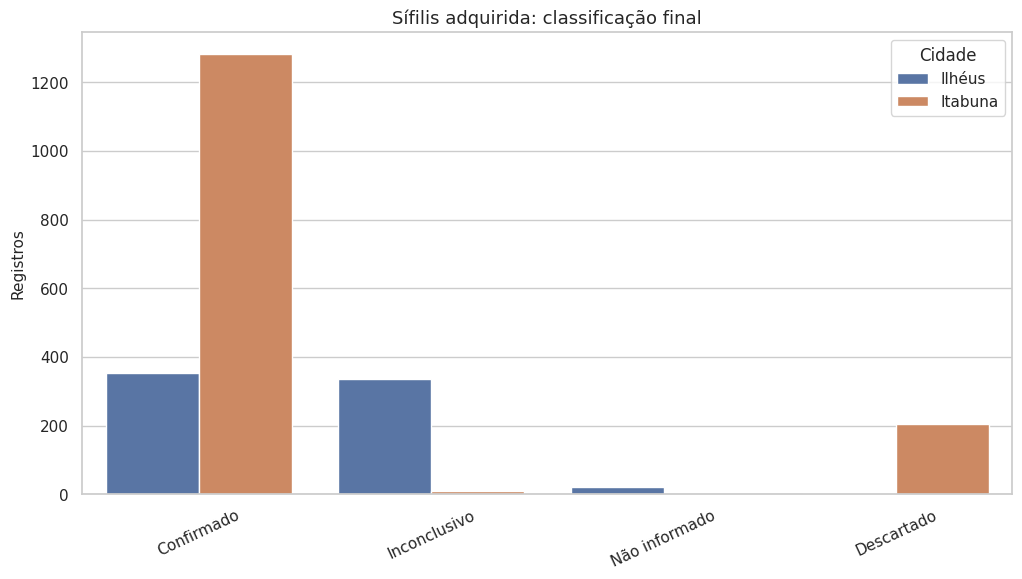

,cidade,classificacao_final,casos,proporcao_pct
4,Itabuna,Confirmado,1281,85.685619
0,Ilhéus,Confirmado,354,49.579832
1,Ilhéus,Inconclusivo,335,46.918768
5,Itabuna,Descartado,205,13.712375
2,Ilhéus,Não informado,22,3.081232
6,Itabuna,Inconclusivo,9,0.602007
3,Ilhéus,Descartado,3,0.420168


In [3]:
plot_barras_categoria(class_sifa, "classificacao_final", "casos", "Sífilis adquirida: classificação final", "05_sifa_classificacao.png")

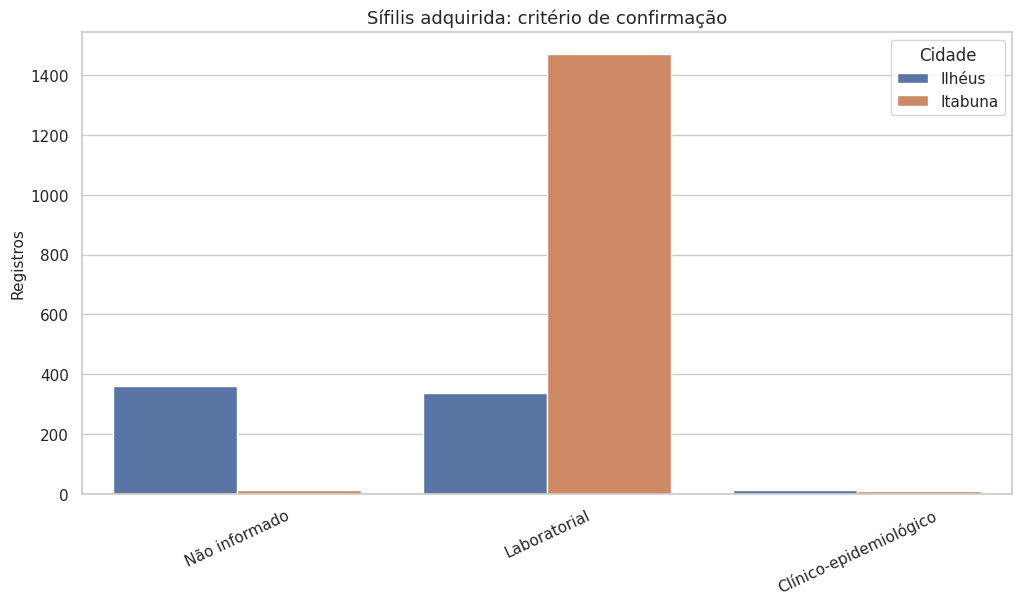

,cidade,criterio_confirmacao,registros
3,Itabuna,Laboratorial,1470
0,Ilhéus,Não informado,362
1,Ilhéus,Laboratorial,339
4,Itabuna,Não informado,14
2,Ilhéus,Clínico-epidemiológico,13
5,Itabuna,Clínico-epidemiológico,11


In [4]:
plot_barras_categoria(sifa_criterio, "criterio_confirmacao", "registros", "Sífilis adquirida: critério de confirmação", "05_sifa_criterio.png")

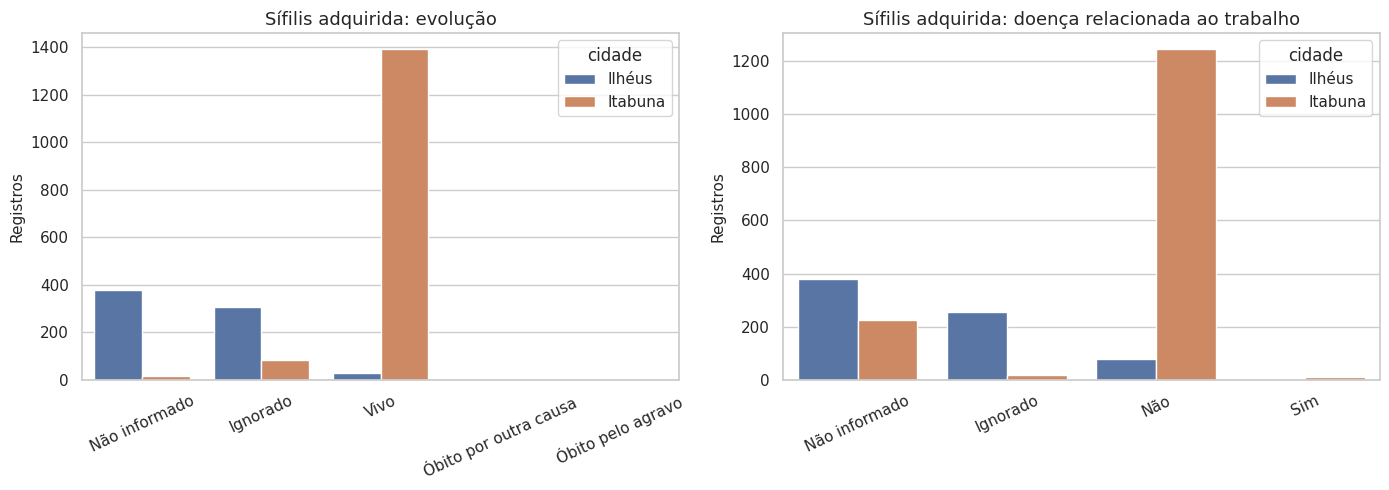

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=sifa_evolucao, x="evolucao", y="registros", hue="cidade", ax=axes[0])
axes[0].set_title("Sífilis adquirida: evolução")
axes[0].set_xlabel("")
axes[0].set_ylabel("Registros")
axes[0].tick_params(axis="x", rotation=25)
sns.barplot(data=sifa_doenca_trabalho, x="DOENCA_TRA_label", y="registros", hue="cidade", ax=axes[1])
axes[1].set_title("Sífilis adquirida: doença relacionada ao trabalho")
axes[1].set_xlabel("")
axes[1].set_ylabel("Registros")
axes[1].tick_params(axis="x", rotation=25)
fig.tight_layout()
salvar_figura(fig, OUTPUT_DIR, "05_sifa_evolucao_trabalho.png")
plt.show()

In [6]:
classificacao_principal = class_sifa.groupby("classificacao_final")["casos"].sum().sort_values(ascending=False).index[0]
criterio_principal = sifa_criterio.groupby("criterio_confirmacao")["registros"].sum().sort_values(ascending=False).index[0]
exibir_markdown(f"""
### Observações sobre sífilis adquirida

No recorte de Ilhéus e Itabuna, a categoria mais frequente em classificação final é `{classificacao_principal}`. No critério de confirmação, a categoria mais frequente é `{criterio_principal}`. A leitura desses campos depende do preenchimento da ficha e deve ser comparada com a completude vista no notebook de qualidade.
""")


### Observações sobre sífilis adquirida

No recorte de Ilhéus e Itabuna, a categoria mais frequente em classificação final é `Confirmado`. No critério de confirmação, a categoria mais frequente é `Laboratorial`. A leitura desses campos depende do preenchimento da ficha e deve ser comparada com a completude vista no notebook de qualidade.


## Sífilis em gestante

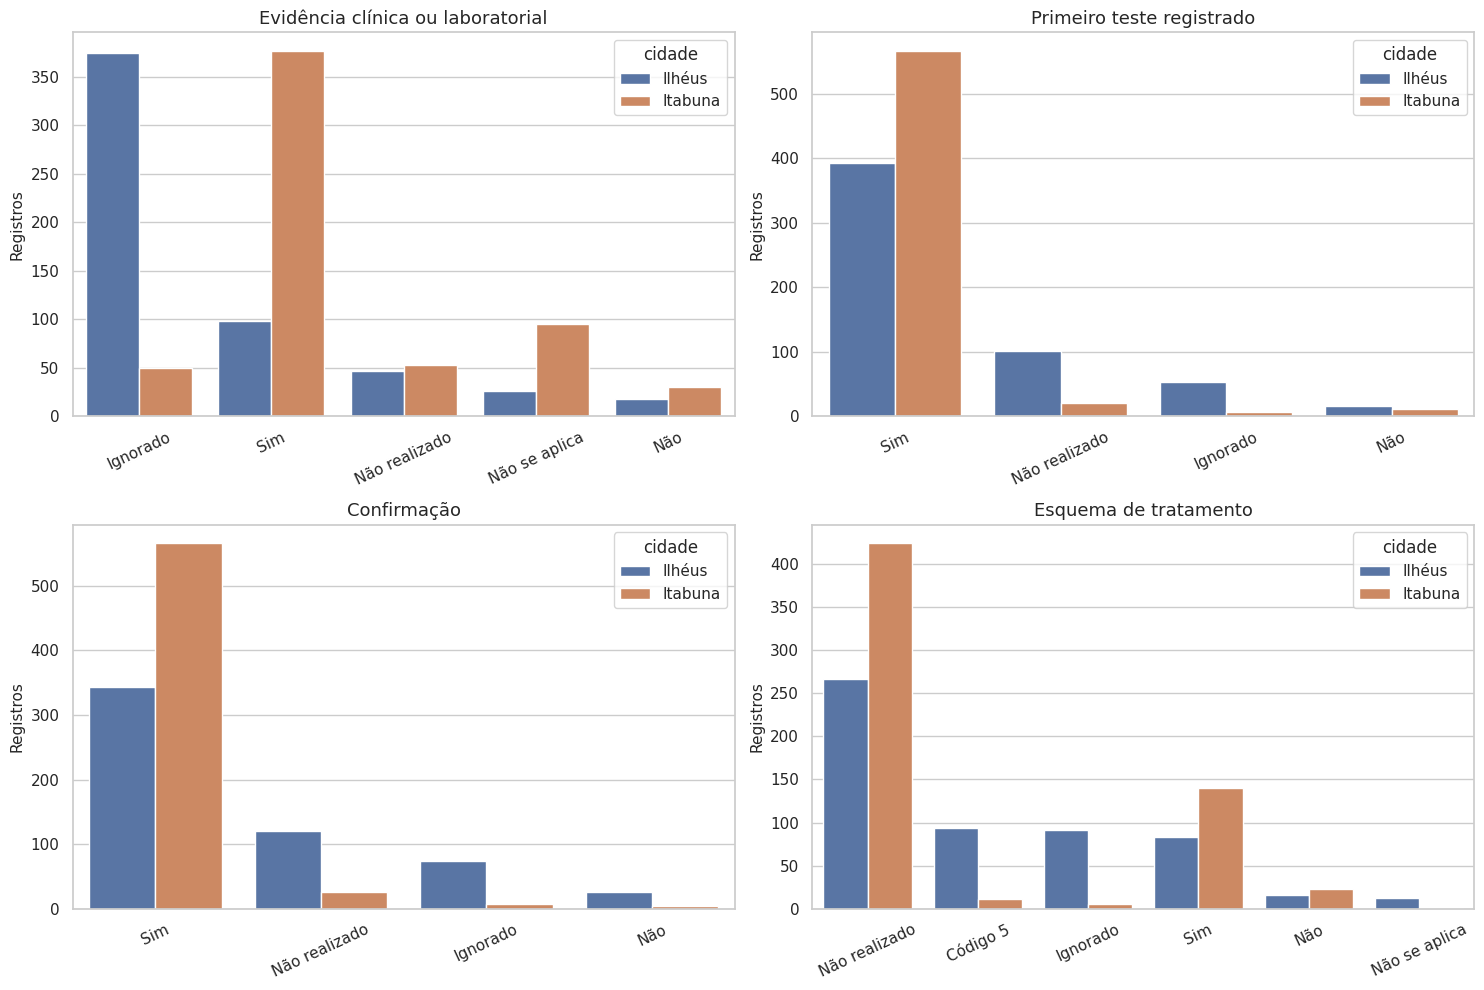

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
campos = [
    ("TPEVIDENCI_label", "Evidência clínica ou laboratorial"),
    ("TPTESTE1_label", "Primeiro teste registrado"),
    ("TPCONFIRMA_label", "Confirmação"),
    ("TPESQUEMA_label", "Esquema de tratamento"),
]
for ax, (campo, titulo) in zip(axes.flat, campos):
    base = sifg_testes[sifg_testes["campo"] == campo]
    principais = base.groupby("categoria")["registros"].sum().sort_values(ascending=False).head(6).index
    sns.barplot(data=base[base["categoria"].isin(principais)], x="categoria", y="registros", hue="cidade", ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("Registros")
    ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
salvar_figura(fig, OUTPUT_DIR, "05_sifg_testes_tratamento.png")
plt.show()

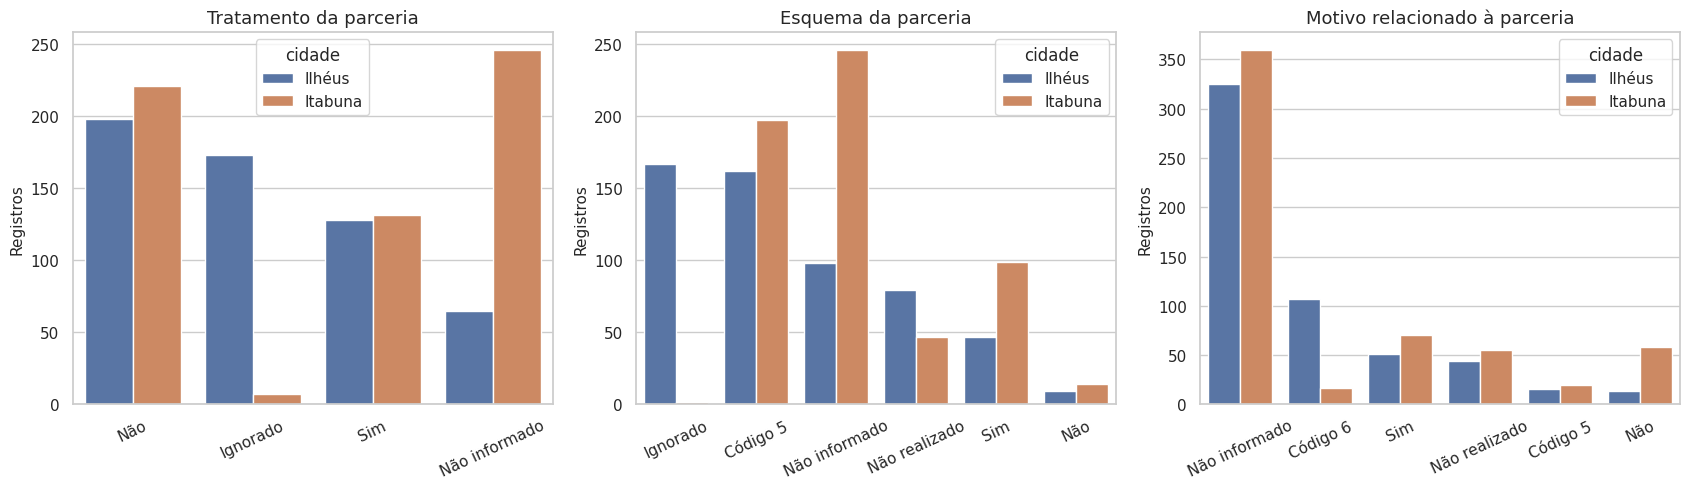

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
campos_parceria = [
    ("TRATPARC_label", "Tratamento da parceria"),
    ("TPESQPAR_label", "Esquema da parceria"),
    ("TPMOTPARC_label", "Motivo relacionado à parceria"),
]
for ax, (campo, titulo) in zip(axes, campos_parceria):
    base = sifg_parceria[sifg_parceria["campo"] == campo]
    principais = base.groupby("categoria")["registros"].sum().sort_values(ascending=False).head(6).index
    sns.barplot(data=base[base["categoria"].isin(principais)], x="categoria", y="registros", hue="cidade", ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("Registros")
    ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
salvar_figura(fig, OUTPUT_DIR, "05_sifg_parceria.png")
plt.show()

In [9]:
trat_parceria = sifg_parceria[sifg_parceria["campo"] == "TRATPARC_label"].groupby("categoria")["registros"].sum().sort_values(ascending=False).head(3)
exibir_markdown(f"""
### Observações sobre sífilis em gestante

A ficha de sífilis em gestante permite observar testagem, confirmação, tratamento e parceria. No campo de tratamento da parceria, as três categorias mais frequentes somam: {', '.join([f'{indice}: {formatar_inteiro(valor)}' for indice, valor in trat_parceria.items()])}. Esses campos devem ser lidos junto com a proporção de registros não informados.
""")


### Observações sobre sífilis em gestante

A ficha de sífilis em gestante permite observar testagem, confirmação, tratamento e parceria. No campo de tratamento da parceria, as três categorias mais frequentes somam: Não: 419, Não informado: 311, Sim: 259. Esses campos devem ser lidos junto com a proporção de registros não informados.


## Sífilis congênita

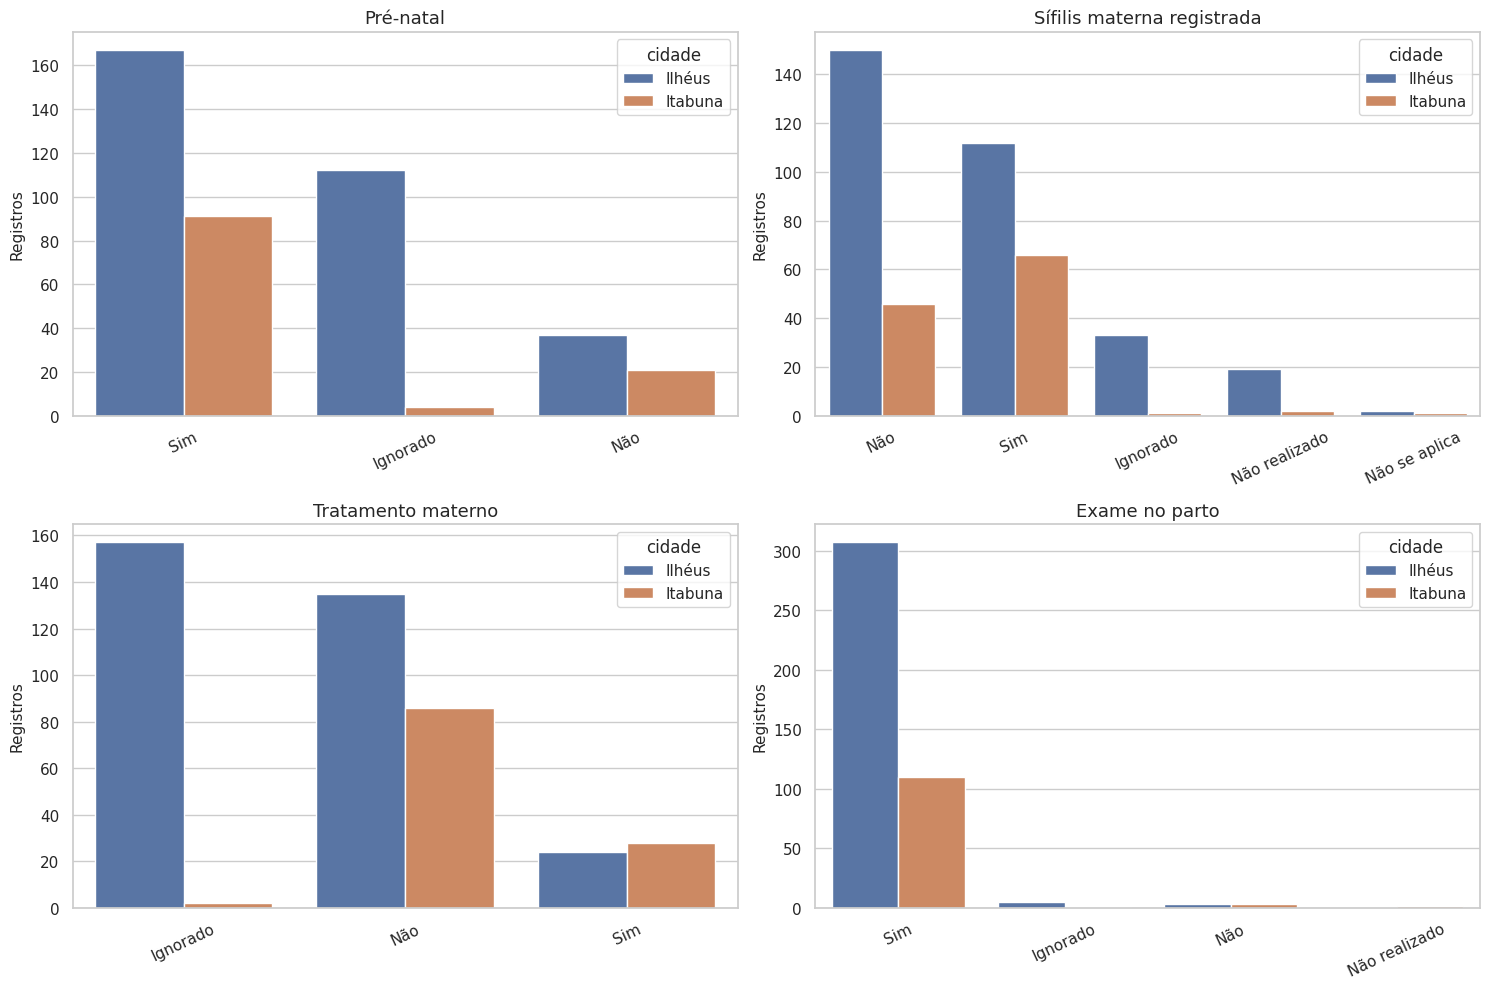

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
campos_congenita = [
    ("ANT_PRE_NA_label", "Pré-natal"),
    ("ANTSIFIL_N_label", "Sífilis materna registrada"),
    ("ANT_TRATAD_label", "Tratamento materno"),
    ("LAB_PARTO_label", "Exame no parto"),
]
for ax, (campo, titulo) in zip(axes.flat, campos_congenita):
    base = sifc_pre_natal[sifc_pre_natal["campo"] == campo]
    principais = base.groupby("categoria")["registros"].sum().sort_values(ascending=False).head(6).index
    sns.barplot(data=base[base["categoria"].isin(principais)], x="categoria", y="registros", hue="cidade", ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("Registros")
    ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
salvar_figura(fig, OUTPUT_DIR, "05_sifc_pre_natal_tratamento.png")
plt.show()

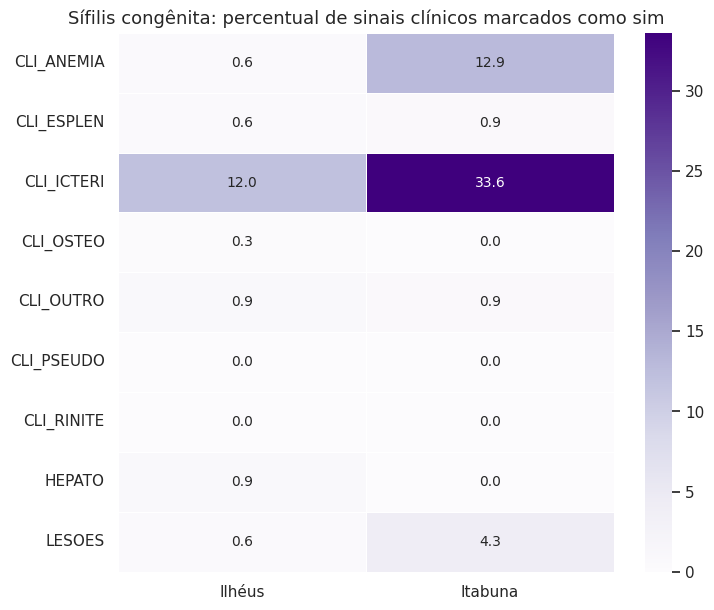

In [11]:
matriz = sifc_sinais.pivot(index="sinal", columns="cidade", values="sim_pct")
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(matriz, annot=True, fmt=".1f", cmap="Purples", linewidths=.4, ax=ax)
ax.set_title("Sífilis congênita: percentual de sinais clínicos marcados como sim")
ax.set_xlabel("")
ax.set_ylabel("")
salvar_figura(fig, OUTPUT_DIR, "05_sifc_sinais_clinicos.png")
plt.show()

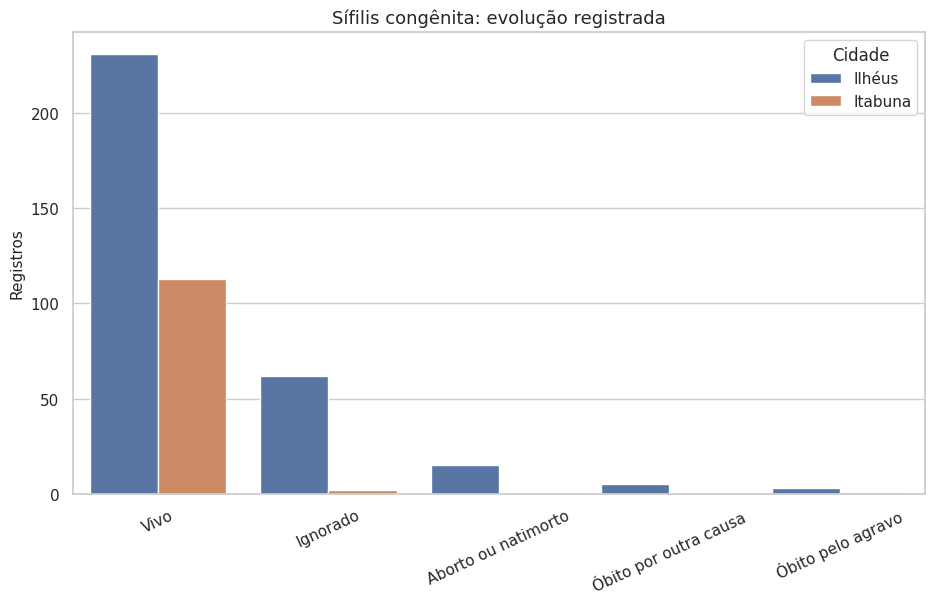

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=sifc_evolucao, x="evolucao", y="registros", hue="cidade", ax=ax)
ax.set_title("Sífilis congênita: evolução registrada")
ax.set_xlabel("")
ax.set_ylabel("Registros")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Cidade")
salvar_figura(fig, OUTPUT_DIR, "05_sifc_evolucao.png")
plt.show()

In [13]:
pre_natal_top = sifc_pre_natal[sifc_pre_natal["campo"] == "ANT_PRE_NA_label"].groupby("categoria")["registros"].sum().sort_values(ascending=False).head(3)
tratamento_top = sifc_pre_natal[sifc_pre_natal["campo"] == "ANT_TRATAD_label"].groupby("categoria")["registros"].sum().sort_values(ascending=False).head(3)
exibir_markdown(f"""
### Observações sobre sífilis congênita

Na sífilis congênita, os campos de pré-natal e tratamento materno ajudam a descrever a trajetória anterior à notificação. No campo de pré-natal, as categorias mais frequentes são: {', '.join([f'{indice}: {formatar_inteiro(valor)}' for indice, valor in pre_natal_top.items()])}. No tratamento materno, as categorias mais frequentes são: {', '.join([f'{indice}: {formatar_inteiro(valor)}' for indice, valor in tratamento_top.items()])}.
""")


### Observações sobre sífilis congênita

Na sífilis congênita, os campos de pré-natal e tratamento materno ajudam a descrever a trajetória anterior à notificação. No campo de pré-natal, as categorias mais frequentes são: Sim: 258, Ignorado: 116, Não: 58. No tratamento materno, as categorias mais frequentes são: Não: 221, Ignorado: 159, Sim: 52.


## Síntese final

As análises específicas usam contagens e proporções. Para sífilis congênita, não foi calculada taxa por nascidos vivos porque essa base não inclui o denominador necessário.

## Bloco complementar — classificação dos casos confirmados, descartados e inconclusivos

A classificação final está preenchida de forma utilizável na base de sífilis adquirida. Nas bases de sífilis em gestante e sífilis congênita, esse campo aparece vazio ou não está disponível nos arquivos analisados.

In [14]:
class_sifa.sort_values(["cidade", "casos"], ascending=[True, False])

,cidade,classificacao_final,casos,proporcao_pct
0,Ilhéus,Confirmado,354,49.579832
1,Ilhéus,Inconclusivo,335,46.918768
2,Ilhéus,Não informado,22,3.081232
3,Ilhéus,Descartado,3,0.420168
4,Itabuna,Confirmado,1281,85.685619
5,Itabuna,Descartado,205,13.712375
6,Itabuna,Inconclusivo,9,0.602007


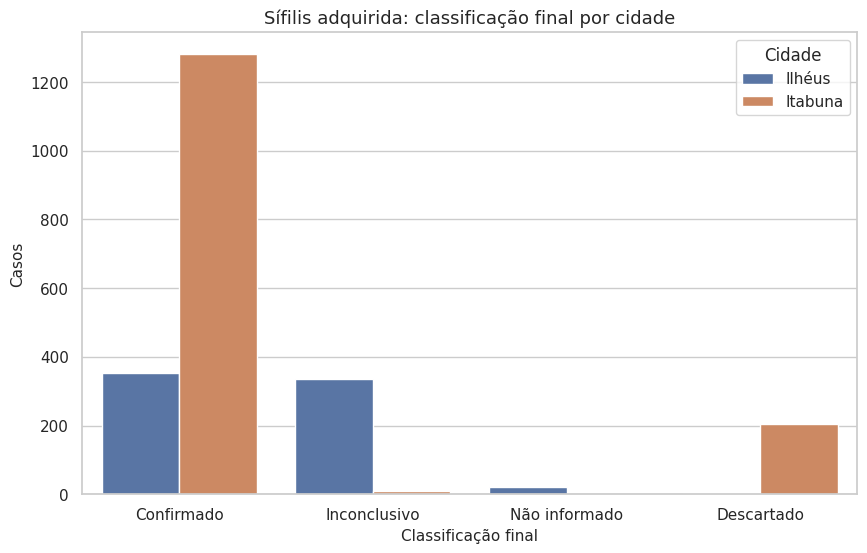

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=class_sifa, x="classificacao_final", y="casos", hue="cidade", ax=ax)
ax.set_title("Sífilis adquirida: classificação final por cidade")
ax.set_xlabel("Classificação final")
ax.set_ylabel("Casos")
ax.legend(title="Cidade")
salvar_figura(fig, OUTPUT_DIR, "05_bloco1_classificacao_lado_a_lado.png")
plt.show()

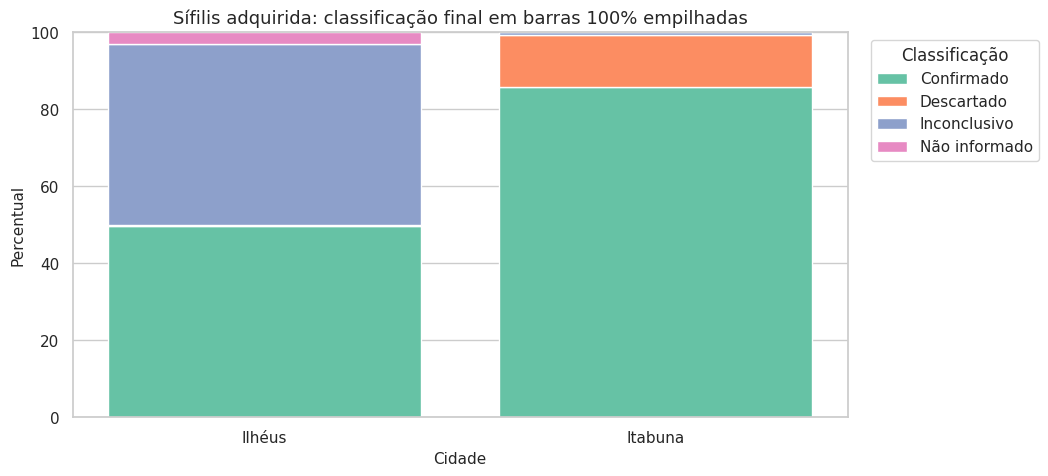

In [16]:
class_pivot = class_sifa.pivot(index="cidade", columns="classificacao_final", values="proporcao_pct").fillna(0)
fig, ax = plt.subplots(figsize=(10, 5))
left = np.zeros(len(class_pivot))
cores = sns.color_palette("Set2", n_colors=len(class_pivot.columns))
for cor, coluna in zip(cores, class_pivot.columns):
    ax.bar(class_pivot.index, class_pivot[coluna], bottom=left, label=coluna, color=cor)
    left += class_pivot[coluna].values
ax.set_title("Sífilis adquirida: classificação final em barras 100% empilhadas")
ax.set_xlabel("Cidade")
ax.set_ylabel("Percentual")
ax.set_ylim(0, 100)
ax.legend(title="Classificação", bbox_to_anchor=(1.02, 1), loc="upper left")
salvar_figura(fig, OUTPUT_DIR, "05_bloco1_classificacao_100_empilhado.png")
plt.show()

In [17]:
linhas = []
for cidade, grupo in class_sifa.groupby("cidade"):
    partes = [f"{row.classificacao_final}: {formatar_percentual(row.proporcao_pct)}" for row in grupo.sort_values("casos", ascending=False).itertuples()]
    linhas.append(f"- {cidade}: " + "; ".join(partes))
exibir_markdown("### Proporção por cidade\n\n" + "\n".join(linhas))

### Proporção por cidade

- Ilhéus: Confirmado: 49,6%; Inconclusivo: 46,9%; Não informado: 3,1%; Descartado: 0,4%
- Itabuna: Confirmado: 85,7%; Descartado: 13,7%; Inconclusivo: 0,6%

## Bloco complementar — unidade de saúde e limitação dos dados

O bloco solicitado por unidade de saúde depende de um campo de unidade notificadora ou CNES. Os arquivos `SIFA`, `SIFG` e `SIFC` disponíveis neste ambiente não trazem esse campo. A checagem abaixo confirma os campos relacionados a município, mas não identifica unidade notificadora.

In [18]:
campos_unidade_df["campos_unidade_encontrados"].value_counts().reset_index(name="arquivos")

,campos_unidade_encontrados,arquivos
0,nenhum,33


In [19]:
if (campos_unidade_df["campos_unidade_encontrados"] == "nenhum").all():
    exibir_markdown("""
### Leitura sobre unidade de saúde

Não há campo de unidade notificadora ou CNES nos 33 CSVs analisados. Por isso, não é possível calcular quais unidades notificaram mais casos, nem a evolução anual por unidade de saúde. Para não substituir uma variável inexistente por outra sem avisar, a análise abaixo usa município de notificação como aproximação territorial, não como unidade de saúde.
""")


### Leitura sobre unidade de saúde

Não há campo de unidade notificadora ou CNES nos 33 CSVs analisados. Por isso, não é possível calcular quais unidades notificaram mais casos, nem a evolução anual por unidade de saúde. Para não substituir uma variável inexistente por outra sem avisar, a análise abaixo usa município de notificação como aproximação territorial, não como unidade de saúde.


In [20]:
notificacao_municipio.groupby(["cidade", "municipio_nome"], as_index=False)["casos"].sum().sort_values(["cidade", "casos"], ascending=[True, False]).head(20)

,cidade,municipio_nome,casos
1,Ilhéus,Ilhéus,1519
2,Ilhéus,Itabuna,48
6,Ilhéus,Salvador,9
10,Ilhéus,Vitória da Conquista,4
0,Ilhéus,Barreiras,3
4,Ilhéus,Porto Seguro,2
3,Ilhéus,Lauro de Freitas,1
5,Ilhéus,Rafael Jambeiro,1
7,Ilhéus,Teixeira de Freitas,1
8,Ilhéus,Una,1


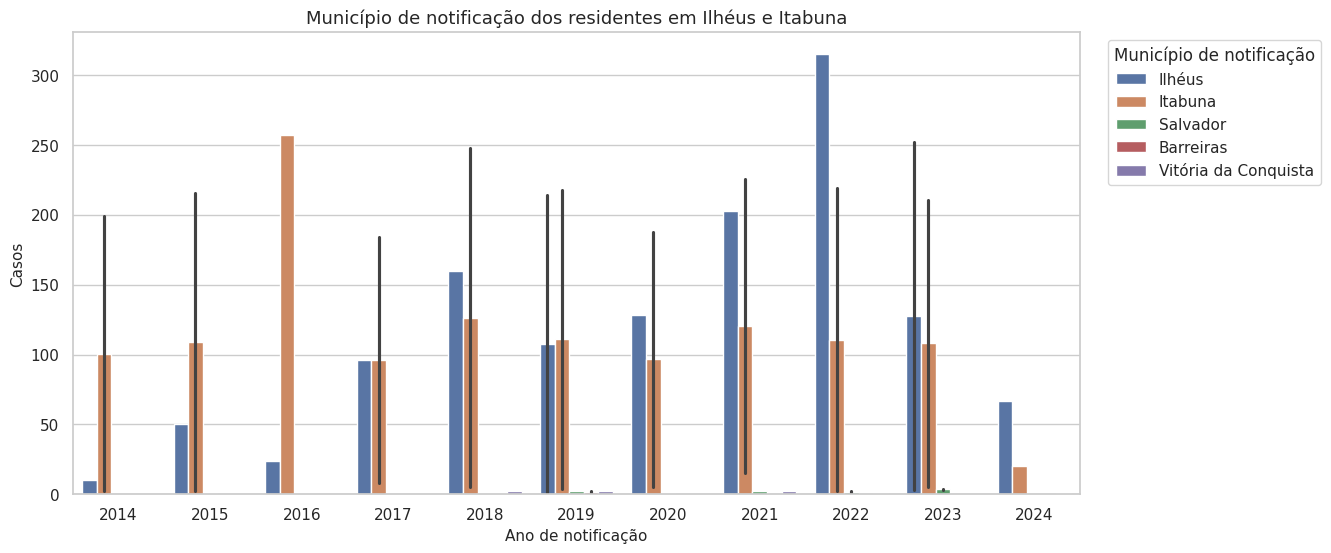

In [21]:
top_municipios_notificacao = (
    notificacao_municipio.groupby(["cidade", "municipio_nome"], as_index=False)["casos"].sum()
    .sort_values(["cidade", "casos"], ascending=[True, False])
    .groupby("cidade")
    .head(5)
)
base_plot = notificacao_municipio.merge(top_municipios_notificacao[["cidade", "municipio_nome"]], on=["cidade", "municipio_nome"], how="inner")
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=base_plot, x="ano_notificacao", y="casos", hue="municipio_nome", ax=ax)
ax.set_title("Município de notificação dos residentes em Ilhéus e Itabuna")
ax.set_xlabel("Ano de notificação")
ax.set_ylabel("Casos")
ax.legend(title="Município de notificação", bbox_to_anchor=(1.02, 1), loc="upper left")
salvar_figura(fig, OUTPUT_DIR, "05_bloco5_municipio_notificacao_proxy.png")
plt.show()